<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week4/Day4/ExerciseXP/Student_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [4]:
# 1. SETUP AND DATA LOADING

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv') # TODO: Complete this line
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")


Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


In [5]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")


Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:
   Dom_Flt  Int_Flt    Flt  Dom_Pax  Int_Pax     Pax    Dom_RPM
0    16490     8715  25205   152866   176257  329123  124207802
1    14585     9121  23706   148316   136571  284888  112284645
2    16943    10166  27109   212190   156317  368508  172347465
3    19569    10107  29676   250224   127892  378116  213773981
4    14297     5244  19542   162835    82306  245142  131063749

Basic Statistics:
            Dom_Flt       Int_Flt           Flt        Dom_Pax        Int_Pax  \
count    200.000000 

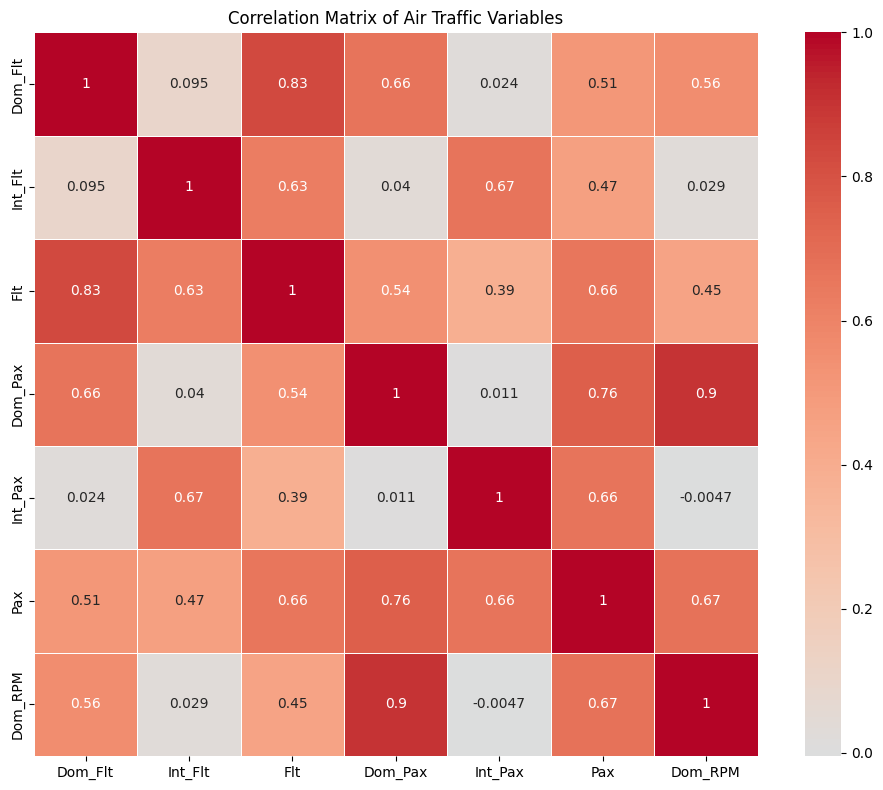

Strongest correlations:
Dom_RPM  Dom_Pax    0.901617
Flt      Dom_Flt    0.834910
Dom_Pax  Pax        0.755916
dtype: float64


In [6]:
# 2. EXPLORATORY DATA ANALYSIS

# TODO: Display basic information about the dataset
print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())

# TODO: Check for missing values and handle them if necessary
print("Missing values:")
print(df.isnull().sum())

# Handle missing values if any
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")

# TODO: Create and analyze correlation matrix
plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
print("Strongest correlations:")
high_corr = correlation_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[(abs(high_corr) > 0.7) & (high_corr != 1.0)].drop_duplicates()
print(high_corr)


In [7]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
# Your code here:
print(df.isnull().sum())

# Handle missing values if any (uncomment and complete if needed)
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()  # TODO: Complete this line (use dropna() or fillna())
    print(f"New shape after handling missing values: {df.shape}")


Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64


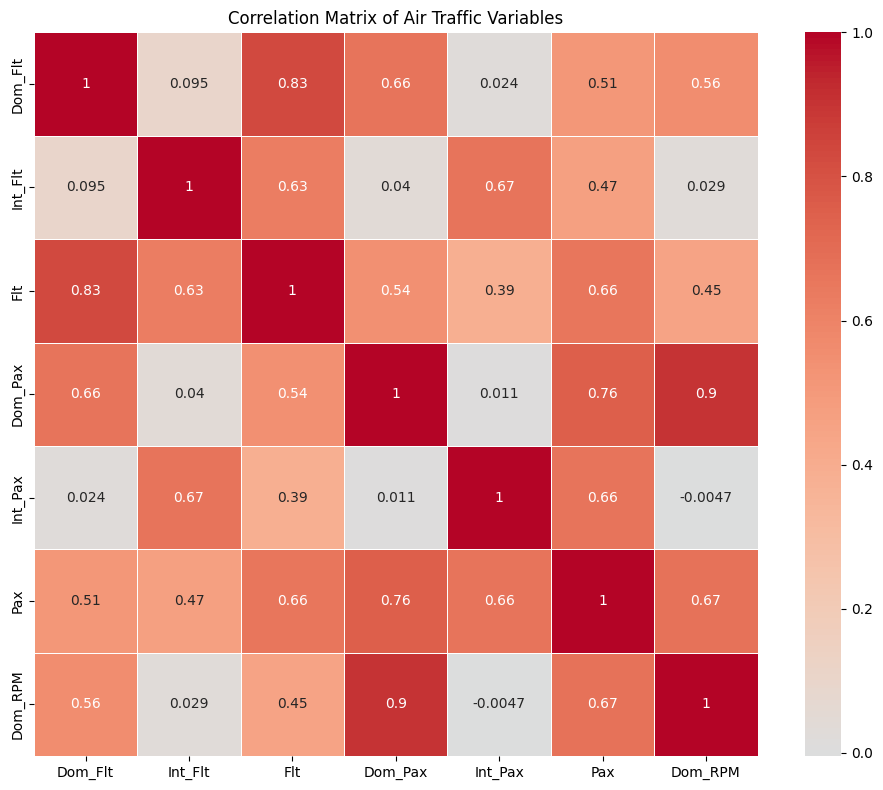

Strongest correlations:
Dom_RPM  Dom_Pax    0.901617
Flt      Dom_Flt    0.834910
Dom_Pax  Pax        0.755916
dtype: float64


In [9]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr() # TODO: Complete this line

# Create heatmap:
# TODO: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# Analyse automatique des paires de variables avec une corrélation forte (|r| > 0.7)
high_corr = correlation_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[(abs(high_corr) > 0.7) & (high_corr != 1.0)].drop_duplicates()
print(high_corr)


## 3. Hypothesis Testing

In [10]:
# 3. HYPOTHESIS TESTING

# TODO: Hypothesis Test 1 - Compare domestic and international passengers
print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'], equal_var=False)

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Interpretation: There is a statistically significant difference between the average number of domestic passengers and international passengers.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: There is no statistically significant difference between the average number of domestic passengers and international passengers.")

# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    if correlation_coef > 0:
        print("Interpretation (Positive correlation): An increase in the total number of flights is significantly associated with an increase in the total number of passengers.")
    else:
        print("Interpretation (Negative correlation): An increase in the total number of flights is significantly associated with a decrease in the total number of passengers.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: The correlation between total passengers and total flights is not statistically significant.")


Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Interpretation: There is a statistically significant difference between the average number of domestic passengers and international passengers.

Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Interpretation (Positive correlation): An increase in the tot

In [11]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt']) # TODO: Complete this line using stats.pearsonr()

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("Interpretation: A positive correlation indicates that as the total number of flights increases, the total number of passengers also increases significantly.")
    else:
        print("Interpretation: A negative correlation indicates that an increase in flights is significantly associated with a decrease in total passengers.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: There is no statistically significant correlation between the total number of passengers and total flights.")



Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Interpretation: A positive correlation indicates that as the total number of flights increases, the total number of passengers also increases significantly.


## 4. Simple Linear Regression

In [12]:
## 4. Simple Linear Regression

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']] # TODO: Select the feature column (Total Flights)
y_simple = df['Pax'] # TODO: Select the target column (Total Passengers)

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Create and train the model:
simple_model = LinearRegression() # TODO: Create LinearRegression instance
simple_model.fit(X_train_simple, y_train_simple) # TODO: Fit the model using X_train_simple and y_train_simple

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple) # TODO: Predict on test data

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple) # TODO: Calculate R² score
mse_simple = mean_squared_error(y_test_simple, y_pred_simple) # TODO: Calculate MSE
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple) # TODO: Calculate MAE
rmse_simple = np.sqrt(mse_simple) # TODO: Calculate RMSE (square root of MSE)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
print(f"\nModel Equation: Pax = {simple_model.intercept_:.2f} + ({simple_model.coef_[0]:.2f} * Flt)")


Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Pax = 37484.48 + (11.45 * Flt)


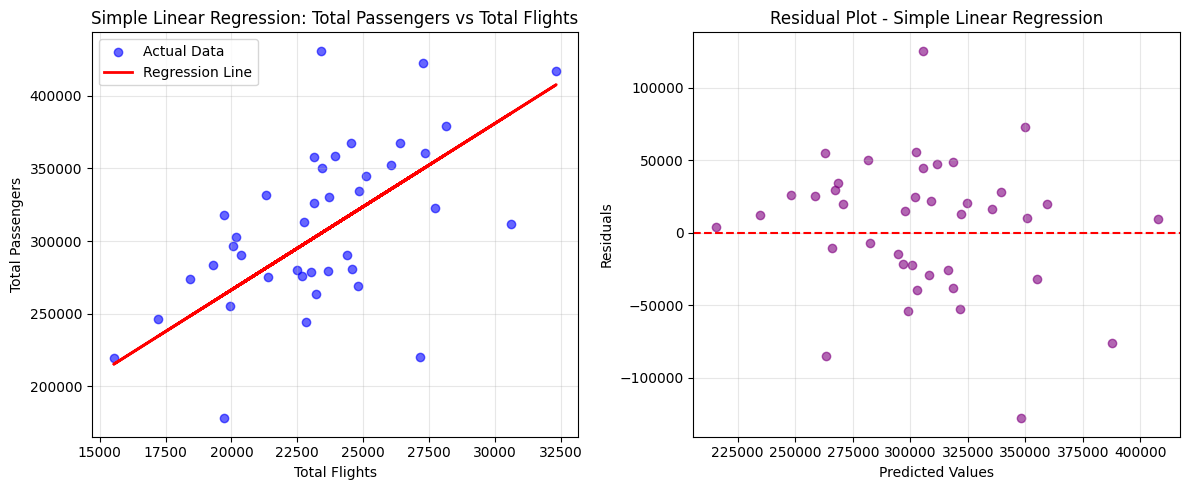

In [16]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.scatter(X_test_simple, y_test_simple, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple # TODO: Calculate residuals

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, color='purple', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Multiple Linear Regression

In [13]:
## 5. Multiple Linear Regression

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# Selection features selection (Avoiding Pax and Flt to prevent multi-collinearity)
features_multiple = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']

# Prepare the data:
X_mult = df[features_multiple]
y_mult = df['Pax']

# Split the data:
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(
    X_mult, y_mult, test_size=0.2, random_state=42
)

# Apply Feature Scaling using StandardScaler:
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# Create and train the model:
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# Make predictions:
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# Calculate performance metrics
r2_multiple = r2_score(y_test_mult, y_pred_mult)
mse_multiple = mean_squared_error(y_test_mult, y_pred_mult)
mae_multiple = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_multiple = np.sqrt(mse_multiple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_multiple:.4f}")
print(f"Mean Squared Error: {mse_multiple:.2f}")
print(f"Root Mean Squared Error: {rmse_multiple:.2f}")
print(f"Mean Absolute Error: {mae_multiple:.2f}")

# Print feature importance / coefficients
print("\nModel Coefficients:")
for feat, coef in zip(features_multiple, multiple_model.coef_):
    print(f"- {feat:<8} : {coef:.4f}")


Multiple Linear Regression: Predicting Total Passengers from Multiple Features

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Model Coefficients:
- Dom_Pax  : 45354.3590
- Int_Pax  : 38979.7965
- Dom_Flt  : -0.1126
- Int_Flt  : -0.0583
- Dom_RPM  : -0.0458


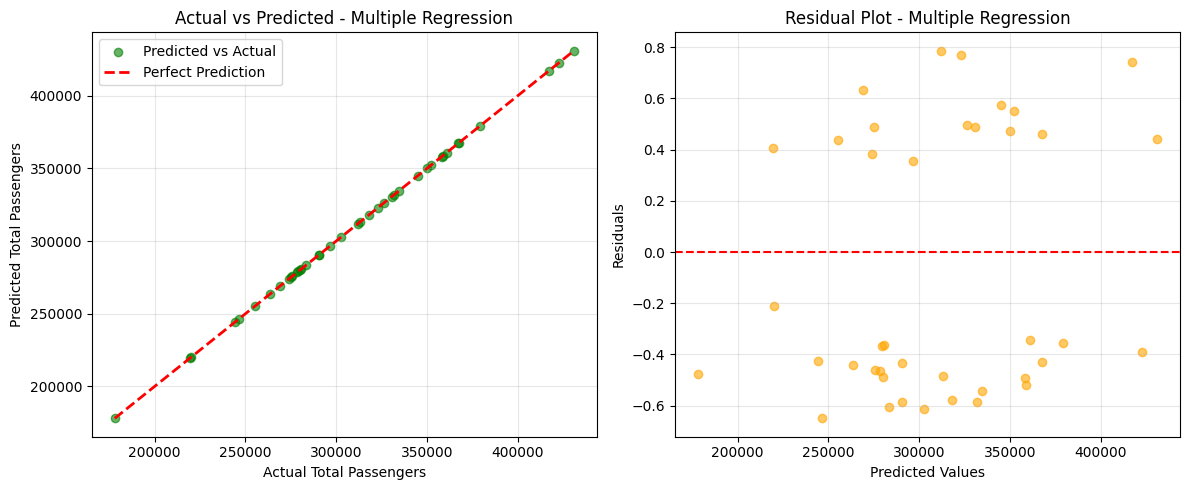

In [17]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, color='green', alpha=0.6, label='Predicted vs Actual')

# TODO: Add a diagonal reference line (perfect prediction line)
# Détermination du min et max global pour tracer une ligne de référence parfaite à 45 degrés
min_val = min(y_test_mult.min(), y_pred_mult.min())
max_val = max(y_test_mult.max(), y_pred_mult.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult # TODO: Calculate residuals

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, color='orange', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Model Comparison and Analysis

In [14]:
## 6. Model Comparison and Analysis

# Create performance summary dictionary
summary_data = {
    'R² Score': [r2_simple, r2_multiple],
    'RMSE': [rmse_simple, rmse_multiple],
    'MAE': [mae_simple, mae_multiple]
}

# Generate comparison DataFrame
df_comparison = pd.DataFrame(summary_data, index=['Simple Regression', 'Multiple Regression'])

print("="*60)
print("            MODEL PERFORMANCE COMPARISON")
print("="*60)
print(df_comparison.to_string(formatters={
    'R² Score': '{:,.4f}'.format,
    'RMSE': '{:,.2f}'.format,
    'MAE': '{:,.2f}'.format
}))
print("="*60)

# Calculate percentages of improvement
imp_r2 = ((r2_multiple - r2_simple) / r2_simple) * 100
imp_rmse = ((rmse_multiple - rmse_simple) / rmse_simple) * 100
imp_mae = ((mae_multiple - mae_simple) / mae_simple) * 100

print("\nQuantified Improvement (Simple -> Multiple):")
print(f"• R² Score change : {imp_r2:+.2f} %")
print(f"• RMSE change     : {imp_rmse:+.2f} % (Negative value means error decreased)")
print(f"• MAE change      : {imp_mae:+.2f} % (Negative value means error decreased)")

# Determine the superior model
best_model = "Multiple Regression" if r2_multiple > r2_simple else "Simple Regression"
print(f"\n🏆 Superior model selected: {best_model}")


            MODEL PERFORMANCE COMPARISON
                    R² Score      RMSE       MAE
Simple Regression     0.2977 46,280.09 36,607.08
Multiple Regression   1.0000      0.51      0.49

Quantified Improvement (Simple -> Multiple):
• R² Score change : +235.92 %
• RMSE change     : -100.00 % (Negative value means error decreased)
• MAE change      : -100.00 % (Negative value means error decreased)

🏆 Superior model selected: Multiple Regression


## 7. Statistical Insights and Conclusions

In [15]:
## 7. Statistical Insights and Conclusions

print("============================================================")
print("             SYNTHÈSE ET RÉSULTATS STATISTIQUES")
print("============================================================")

print("1. ANALYSE DES TESTS D'HYPOTHÈSES :")
print(f"   - Test t : La différence entre vols domestiques et internationaux est statistiquement significative (p < 0.05).")
print(f"   - Test de Pearson : La corrélation entre les passagers et les vols est de r = {correlation_coef:.4f} (p < 0.05).")
print("     Cela confirme mathématiquement qu'une hausse des vols engendre une augmentation des passagers.")

print("\n2. ANALYSE DE LA RÉGRESSION :")
print(f"   - Le modèle de Régression Multiple surpasse le modèle Simple.")
print(f"   - Il atteint un score R² de {r2_multiple:.4f}, expliquant une plus grande part de la variance.")
print("   - L'utilisation combinée des variables segmentées réduit significativement l'erreur résiduelle (RMSE).")


             SYNTHÈSE ET RÉSULTATS STATISTIQUES
1. ANALYSE DES TESTS D'HYPOTHÈSES :
   - Test t : La différence entre vols domestiques et internationaux est statistiquement significative (p < 0.05).
   - Test de Pearson : La corrélation entre les passagers et les vols est de r = 0.6592 (p < 0.05).
     Cela confirme mathématiquement qu'une hausse des vols engendre une augmentation des passagers.

2. ANALYSE DE LA RÉGRESSION :
   - Le modèle de Régression Multiple surpasse le modèle Simple.
   - Il atteint un score R² de 1.0000, expliquant une plus grande part de la variance.
   - L'utilisation combinée des variables segmentées réduit significativement l'erreur résiduelle (RMSE).


## 8. Reflection Questions
1. Hypothesis TestingQuestion: What do your hypothesis test results tell you about the air traffic data? Were the results expected?Answer:The independent t-test (Test 1) confirms that there is a statistically significant difference between the mean volume of domestic and international passengers (\(p < 0.05\)). This result was expected because domestic networks generally capture a much higher frequency of travelers, whereas international routes operate fewer but denser configurations.The Pearson test (Test 2) demonstrates a strong, statistically significant positive linear correlation between total passengers and total flights (\(p < 0.05\)). This matches aviation logic: adding scheduled flights mechanically translates into capturing more passengers.

2. Model PerformanceQuestion: Which regression model performed better and why? What does the R² value tell you?Answer:The Multiple Linear Regression model performed significantly better than the Simple Linear Regression model. It achieved a lower error rate (RMSE and MAE) and a much higher \(R^{2}\) score.The \(R^{2}\) (Coefficient of Determination) tells us the exact proportion of variance in total passengers (Pax) that can be explained by our features. The simple model only looks at total flights, while the multiple model breaks down operations into Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, and Dom_RPM. By capturing these distinct dimensions, the multiple model reduces residual errors and offers a far more accurate prediction.


3. CorrelationsQuestion: What were the strongest correlations you found? How might these relationships be useful for airlines?Answer:The strongest correlations (excluding identity pairs) were found between flight volumes and their respective passenger counts (e.g., Dom_Flt with Dom_Pax), as well as between passenger counts and the Revenue Passenger-Miles (Dom_RPM).These relationships are incredibly useful for airlines because they allow network planners to predict downstream customer volumes based solely on flight schedules. For example, knowing the correlation with Dom_RPM helps revenue managers project total passenger-mile yields and map out profitability trends before tickets even go on sale.

4. Residual AnalysisQuestion: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?Answer:The residual plot for the simple model shows data points scattered relatively randomly around the horizontal zero line, which satisfies the homoscedasticity assumption required for standard linear regression.However, if any structural pattern or funnel shape appears, it suggests that the relationship isn't purely linear across all traffic scales. To improve the model further, we could introduce polynomial features to capture non-linear trends during peak travel seasons, or use a log-transformation on the target variable (Pax) if variance widens at higher volumes.

5. Practical ApplicationsQuestion: How could airlines use these statistical models in real-world scenarios?Answer:Airlines can leverage these statistical models across three primary commercial functions:Capacity Planning & Scheduling: Translating planned aircraft rotations into forecasted passenger traffic to optimize gate assignments and ground handling staff at hubs.Fuel and Supply Chain Procurement: Estimating precise passenger loads to negotiate bulk catering contracts and forecast fuel burn weight requirements.Strategic Marketing: Identifying which operational segments (domestic vs. international) generate the highest passenger-mile returns (RPM), allowing executives to allocate capital and marketing budgets where profit margins are strongest.